# Python Exercises - Pandas

## Problem 1


Imagine three people, e.g. family, friends, cohort.

Create a pandas data frame called `cities_df` that contains the following columns:

* Cities - At least 5 cities in the US
* States - The states that those cities reside in
* Region - The region that those cities reside in (NW, SW, Midwest, etc.)
* Times_1 - The number of times person 1 has been to each city
* Times_2 - The number of times person 2 has been to each city
* Times_3 - The number of times person 3 has been to each city


In [1]:
import pandas as pd

In [2]:
cities_df = pd.DataFrame({
    'Cities': ['Atlanta', 'Albuquerque', 'Sandy', 'El Paso', 'Denver'],
    'States': ['Georgia', 'New Mexico', 'Utah', 'Texas', 'Colorado'],
    'Region': ['South', 'Southwest', 'Southwest', 'West', 'West'],
    'Times_1': [0, 1, 2, 3, 4],
    'Times_2': [12, 5, 3, 2, 4],
    'Times_3': [0, 0, 6, 0, 2],
})

cities_df

,Cities,States,Region,Times_1,Times_2,Times_3
0,Atlanta,Georgia,South,0,12,0
1,Albuquerque,New Mexico,Southwest,1,5,0
2,Sandy,Utah,Southwest,2,3,6
3,El Paso,Texas,West,3,2,0
4,Denver,Colorado,West,4,4,2


## Problem 2


Use the `.describe()` and `.info()` methods on your data frame


In [3]:
cities_df.describe()

,Times_1,Times_2,Times_3
count,5.000000,5.000000,5.000000
mean,2.000000,5.200000,1.600000
std,1.581139,3.962323,2.607681
min,0.000000,2.000000,0.000000
25%,1.000000,3.000000,0.000000
50%,2.000000,4.000000,0.000000
75%,3.000000,5.000000,2.000000
max,4.000000,12.000000,6.000000


In [4]:
cities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Cities   5 non-null      object
 1   States   5 non-null      object
 2   Region   5 non-null      object
 3   Times_1  5 non-null      int64 
 4   Times_2  5 non-null      int64 
 5   Times_3  5 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 372.0+ bytes


## Problem 3


Use indexing to access the Cities column

In [5]:
cities_df.Cities

,Cities
0,Atlanta
1,Albuquerque
2,Sandy
3,El Paso
4,Denver


## Problem 4


Create a new column called `Total_Times` that contains the total number of times all team members have been to each city.

In [6]:
cities_df['total_times'] = cities_df[['Times_1', 'Times_2', 'Times_3']].sum(axis=1)

cities_df

,Cities,States,Region,Times_1,Times_2,Times_3,total_times
0,Atlanta,Georgia,South,0,12,0,12
1,Albuquerque,New Mexico,Southwest,1,5,0,6
2,Sandy,Utah,Southwest,2,3,6,11
3,El Paso,Texas,West,3,2,0,5
4,Denver,Colorado,West,4,4,2,10


## Problem 5


Use indexing to access the cities that have been travelled to more than two times.

In [7]:
cities_df[cities_df['total_times'] > 2]

,Cities,States,Region,Times_1,Times_2,Times_3,total_times
0,Atlanta,Georgia,South,0,12,0,12
1,Albuquerque,New Mexico,Southwest,1,5,0,6
2,Sandy,Utah,Southwest,2,3,6,11
3,El Paso,Texas,West,3,2,0,5
4,Denver,Colorado,West,4,4,2,10


## Problem 6


Make a bar plot with `Cities` on the x axis and `Total_Times` on the y axis.

In [8]:
import matplotlib.pyplot as plt

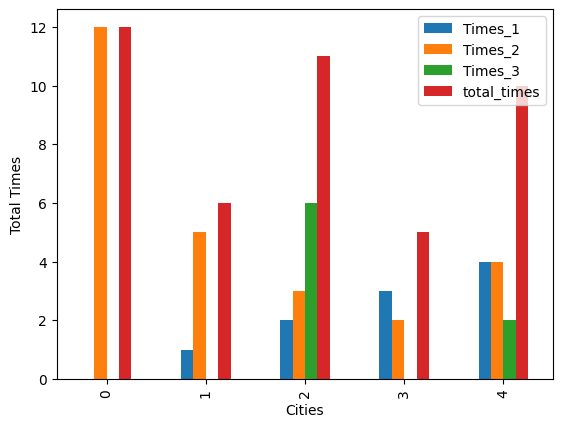

In [9]:
cities_df.plot(kind='bar')

plt.xlabel('Cities')
plt.ylabel('Total Times')
plt.show()

## Problem 7


Drop the 'Total_Times' column from your data frame.

In [10]:
cities_df = cities_df.drop(columns = ['total_times'])
cities_df

,Cities,States,Region,Times_1,Times_2,Times_3
0,Atlanta,Georgia,South,0,12,0
1,Albuquerque,New Mexico,Southwest,1,5,0
2,Sandy,Utah,Southwest,2,3,6
3,El Paso,Texas,West,3,2,0
4,Denver,Colorado,West,4,4,2


## Problem 8


Restructure your data frame using the pandas `.melt()` method. In the `.melt()` method, specify `id_vars = ['Cities', 'States', 'Region']`. Save the melted data frame as a new variable called `cities_df_melted`. Print out `cities_df_melted`.

> Note: make sure to read through the documentation for the `.melt()` method to understand what the method does.

In [11]:
cities_df_melted = cities_df.melt(id_vars=["Cities", "States", "Region"])

cities_df_melted

,Cities,States,Region,variable,value
0,Atlanta,Georgia,South,Times_1,0
1,Albuquerque,New Mexico,Southwest,Times_1,1
2,Sandy,Utah,Southwest,Times_1,2
3,El Paso,Texas,West,Times_1,3
4,Denver,Colorado,West,Times_1,4
5,Atlanta,Georgia,South,Times_2,12
6,Albuquerque,New Mexico,Southwest,Times_2,5
7,Sandy,Utah,Southwest,Times_2,3
8,El Paso,Texas,West,Times_2,2
9,Denver,Colorado,West,Times_2,4


## Problem 9


Use the seaborn `barplot()` function to create a barplot of `cities_df_melted` with `Cities` on the x axis, `value` on the y axis and the hue parameter set to `variable`.

In [12]:
import seaborn as sns

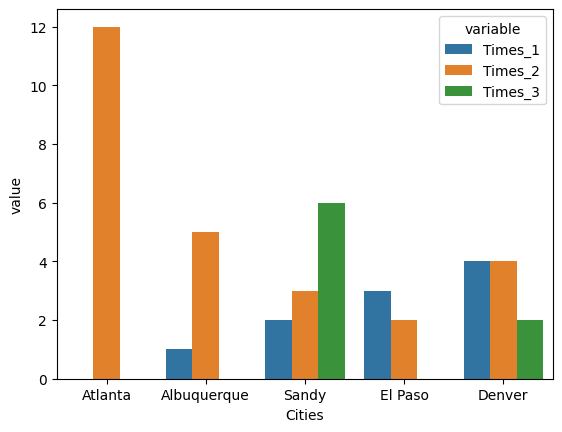

In [14]:
sns.barplot(
    data = cities_df_melted,
    x = 'Cities',
    y = 'value',
    hue = 'variable'
)

plt.show()